In [3]:
import openmc
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

def generate_nuscale_assembly(enrichment=0.045, boron_ppm=975.0, particles=10000, batches=50):
    """
    NuScale NuFuel HTP2™ Standart 17x17 Yakıt Demeti Modellemesi
    Tüm inç birimleri OpenMC için cm'ye dönüştürülmüştür.
    """
    print(f"NuScale NuFuel HTP2™ Modeli Oluşturuluyor (Zenginlik: %{enrichment*100}, Bor: {boron_ppm} ppm)")

    # 1. MALZEME TANIMLAMALARI
    # UO2 Yakıt Seramik Pellet (Yoğunluk: ~10.42 g/cm3)
    fuel = openmc.Material(name='NuScale_UO2')
    fuel.set_density('g/cm3', 10.42)
    m_u = enrichment * 235.04 + (1.0 - enrichment) * 238.05
    m_o2 = 2 * 15.995 # O16 atomik kütlesi referans alındı
    m_uo2 = m_u + m_o2
    fuel.add_nuclide('U235', enrichment * (m_u / m_uo2), 'wo')
    fuel.add_nuclide('U238', (1.0 - enrichment) * (m_u / m_uo2), 'wo')
    fuel.add_nuclide('O16', m_o2 / m_uo2, 'wo')

    # Dikişsiz M5® Gelişmiş Zirkonyum Alaşımı Kılıf (Yoğunluk: ~6.55 g/cm3)
    # M5 alaşımı ağırlıklı olarak Zr (%98.85) ve Nb (%1.0) içerir.
    clad = openmc.Material(name='NuScale_Clad_M5')
    clad.set_density('g/cm3', 6.55)
    clad.add_element('Zr', 0.9885, 'wo')
    clad.add_element('Nb', 0.0100, 'wo')
    clad.add_nuclide('O16', 0.0015, 'wo')

    # Helyum Boşluğu (Gaz)
    helium = openmc.Material(name='NuScale_Gap_He')
    helium.set_density('g/cm3', 0.001598)
    helium.add_element('He', 1.0)

    # Borlu Hafif Su Soğutucu/Moderatör (Sıcak işletme yoğunluğu: ~0.740582 g/cm3)
    water = openmc.Material(name='NuScale_Water')
    water.set_density('g/cm3', 0.740582)
    water.temperature = 566.5 # NuScale ortalama çalışma sıcaklığı (Kelvin)
    
    boron_wt = boron_ppm * 1e-6
    water_wt = 1.0 - boron_wt
    m_H2O = 2 * 1.008 + 15.999
    water.add_element('H', water_wt * (2 * 1.008) / m_H2O, 'wo')
    water.add_nuclide('O16', water_wt * 15.995 / m_H2O, 'wo')
    water.add_element('B', boron_wt, 'wo')

    materials = openmc.Materials([fuel, clad, helium, water])
    materials.export_to_xml()

    # 2. GEOMETRİK BOYUTLAR (İnç -> Cm Dönüşümleri)
    # Pelet Çapı: 0.3195 inç -> Yarıçap: 0.15975 inç -> 0.405765 cm
    r_pellet = openmc.ZCylinder(r=0.3195 * 2.54 / 2.0)
    
    # Çubuk İç Çapı: 0.326 inç -> Yarıçap: 0.163 inç -> 0.41402 cm (Helyum gaz sınırı)
    r_gap = openmc.ZCylinder(r=0.326 * 2.54 / 2.0)
    
    # Çubuk Dış Çapı: 0.374 inç -> Yarıçap: 0.187 inç -> 0.47498 cm (M5 Kılıf dış sınırı)
    r_clad = openmc.ZCylinder(r=0.374 * 2.54 / 2.0)
    
    # Kılavuz Tüp Dış Çapı: 0.482 inç -> Yarıçap: 0.241 inç -> 0.61214 cm
    # Kılavuz Tüp İç Çapı: 0.450 inç -> Yarıçap: 0.225 inç -> 0.57150 cm (Üst bölge referansı)
    r_gt_in = openmc.ZCylinder(r=0.450 * 2.54 / 2.0)
    r_gt_out = openmc.ZCylinder(r=0.482 * 2.54 / 2.0)

    # 2.1 Hücrelerin Evrenlere (Universe) Dağıtılması
    # Yakıt Pini Hücreleri
    c_fuel = openmc.Cell(fill=fuel, region=-r_pellet)
    c_gap = openmc.Cell(fill=helium, region=+r_pellet & -r_gap)
    c_clad = openmc.Cell(fill=clad, region=+r_gap & -r_clad)
    c_water = openmc.Cell(fill=water, region=+r_clad)
    fuel_univ = openmc.Universe(cells=[c_fuel, c_gap, c_clad, c_water])

    # Kılavuz Tüp / Enstrümantasyon Tüp Hücreleri
    c_gt_inner = openmc.Cell(fill=water, region=-r_gt_in)
    c_gt_clad = openmc.Cell(fill=clad, region=+r_gt_in & -r_gt_out)
    c_gt_water = openmc.Cell(fill=water, region=+r_gt_out)
    gt_univ = openmc.Universe(cells=[c_gt_inner, c_gt_clad, c_gt_water])

    # 3. MATRİS (LATTICE) VE REFLREKTİF ADIM AYARLARI
    # Rod Pitch: 0.496 inç -> 1.25984 cm
    rod_pitch = 0.496 * 2.54
    
    # Assembly Genişlik Sınırı (17 * rod_pitch)
    offset = (17 * rod_pitch) / 2.0

    lattice = openmc.RectLattice()
    lattice.pitch = (rod_pitch, rod_pitch)
    lattice.lower_left = (-offset, -offset)
    
    F = fuel_univ
    G = gt_univ
    
    # Standart 17x17 NuScale / Westinghouse Kılavuz Tüp Şeması
    lattice.universes = [
        [F, F, F, F, F, F, F, F, F, F, F, F, F, F, F, F, F],
        [F, F, F, F, F, F, F, F, F, F, F, F, F, F, F, F, F],
        [F, F, F, F, F, G, F, F, G, F, F, G, F, F, F, F, F],
        [F, F, F, G, F, F, F, F, F, F, F, F, F, G, F, F, F],
        [F, F, F, F, F, F, F, F, F, F, F, F, F, F, F, F, F],
        [F, F, G, F, F, G, F, F, G, F, F, G, F, F, G, F, F],
        [F, F, F, F, F, F, F, F, F, F, F, F, F, F, F, F, F],
        [F, F, F, F, F, F, F, F, F, F, F, F, F, F, F, F, F],
        [F, F, G, F, F, G, F, F, G, F, F, G, F, F, G, F, F], # Merkez tüpü
        [F, F, F, F, F, F, F, F, F, F, F, F, F, F, F, F, F],
        [F, F, F, F, F, F, F, F, F, F, F, F, F, F, F, F, F],
        [F, F, G, F, F, G, F, F, G, F, F, G, F, F, G, F, F],
        [F, F, F, F, F, F, F, F, F, F, F, F, F, F, F, F, F],
        [F, F, F, G, F, F, F, F, F, F, F, F, F, G, F, F, F],
        [F, F, F, F, F, G, F, F, G, F, F, G, F, F, F, F, F],
        [F, F, F, F, F, F, F, F, F, F, F, F, F, F, F, F, F],
        [F, F, F, F, F, F, F, F, F, F, F, F, F, F, F, F, F]
    ]
    lattice.outer = openmc.Universe(cells=[openmc.Cell(fill=water)])

    # NuScale Aktif Yakıt Uzunluğu: 78.74 inç -> 200.0 cm
    # Merkez z=0 kabul edilerek -100 ile +100 cm arasına hapsedilir.
    min_x = openmc.XPlane(x0=-offset, boundary_type='reflective')
    max_x = openmc.XPlane(x0=offset, boundary_type='reflective')
    min_y = openmc.YPlane(y0=-offset, boundary_type='reflective')
    max_y = openmc.YPlane(y0=offset, boundary_type='reflective')
    min_z = openmc.ZPlane(z0=-100.0, boundary_type='reflective')
    max_z = openmc.ZPlane(z0=100.0, boundary_type='reflective')

    core_box = +min_x & -max_x & +min_y & -max_y & +min_z & -max_z
    main_cell = openmc.Cell(fill=lattice, region=core_box)
    geometry = openmc.Geometry([main_cell])
    geometry.export_to_xml()

    # 4. AYARLAR VE ÇOKLU ANALİZ SENSÖRLERİ (TALLIES)
    settings = openmc.Settings()
    settings.batches = batches
    settings.inactive = max(10, int(batches * 0.2))
    settings.particles = particles
    settings.temperature = {'method': 'interpolation'}
    
    spatial_dist = openmc.stats.Box((-offset, -offset, -100), (offset, offset, 100))
    settings.source = openmc.IndependentSource(space=spatial_dist, constraints={'fissionable': True})
    settings.export_to_xml()

    #  170x170 çözünürlüklü süper sensör
    mesh = openmc.RegularMesh()
    mesh.dimension = [170, 170]
    mesh.lower_left = [-offset, -offset]
    mesh.upper_right = [offset, offset]
    
    super_tally = openmc.Tally(name='NuScale_Analiz_Tally')
    super_tally.filters = [openmc.MeshFilter(mesh)]
    super_tally.scores = ['flux', 'fission', 'absorption']
    
    tallies = openmc.Tallies([super_tally])
    tallies.export_to_xml()

    print("NuScale XML dosyaları başarıyla üretildi.")
    return offset

In [4]:
nuscale_offset = generate_nuscale_assembly(
    enrichment=0.045,  # NuScale %4.5 zenginleştirilmiş UO2
    boron_ppm=975.0,   # 975 ppm borlu soğutucu su
    particles=10000,   # Doğruluk oranı
    batches=60         # Isınma + aktif nesiller
)

openmc.config['cross_sections'] = 'endfb-vii.1-hdf5/cross_sections.xml'
print("\n--- NuScale NuFuel HTP2 SIMÜLASYONU ---\n")
openmc.run()

NuScale NuFuel HTP2™ Modeli Oluşturuluyor (Zenginlik: %4.5, Bor: 975.0 ppm)
NuScale XML dosyaları başarıyla üretildi.

--- NuScale NuFuel HTP2 SIMÜLASYONU ---

                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
    


NuScale verileri HDF5'ten okunuyor


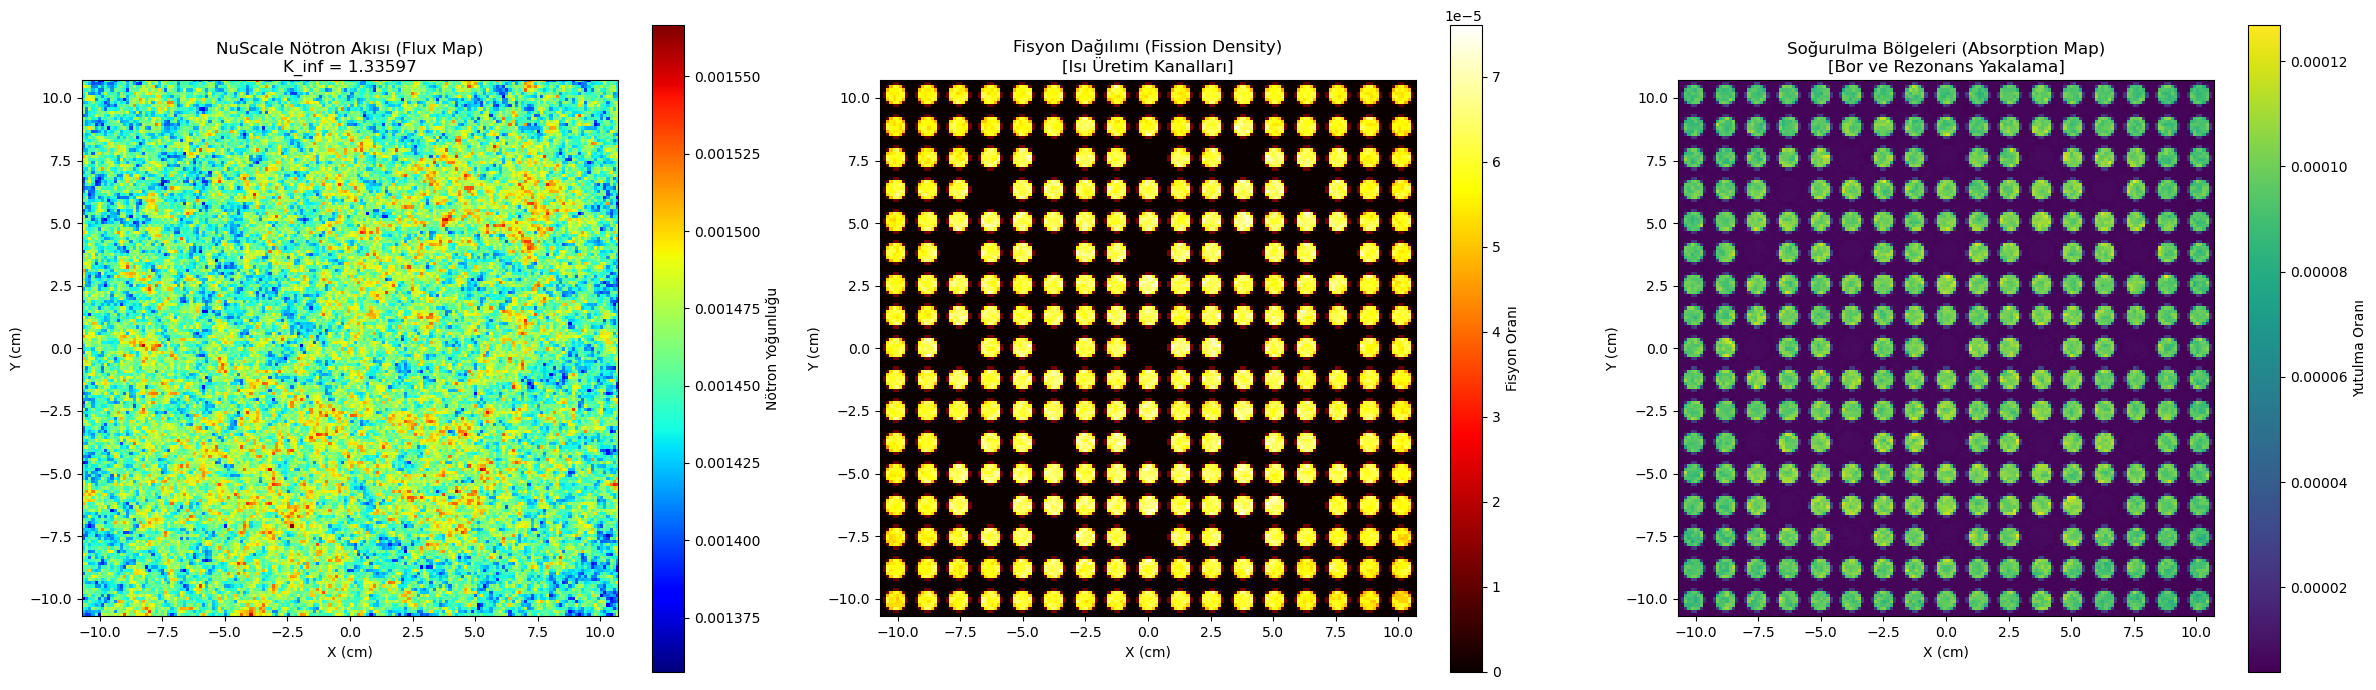

In [5]:
import h5py
import glob

print("\nNuScale verileri HDF5'ten okunuyor")
statepoint_files = glob.glob('statepoint.*.h5')
latest_sp = max(statepoint_files, key=os.path.getctime)

with openmc.StatePoint(latest_sp) as sp:
    k_inf = sp.keff
    tally = sp.get_tally(name='NuScale_Analiz_Tally')
    
    # Slicing
    flux_matrix = tally.get_slice(scores=['flux']).mean.reshape((170, 170))
    fission_matrix = tally.get_slice(scores=['fission']).mean.reshape((170, 170))
    absorption_matrix = tally.get_slice(scores=['absorption']).mean.reshape((170, 170))

# Yön düzeltmeleri
flux_matrix = np.flipud(flux_matrix)
fission_matrix = np.flipud(fission_matrix)
absorption_matrix = np.flipud(absorption_matrix)

# 3'LÜ PANEL GÖRSELLEŞTİRME
fig, axes = plt.subplots(1, 3, figsize=(24, 7))
ext = [-nuscale_offset, nuscale_offset, -nuscale_offset, nuscale_offset]

# 1. Nötron Akısı
im0 = axes[0].imshow(flux_matrix, interpolation='nearest', cmap='jet', extent=ext)
axes[0].set_title(f'NuScale Nötron Akısı (Flux Map)\nK_inf = {k_inf.nominal_value:.5f}')
fig.colorbar(im0, ax=axes[0], label='Nötron Yoğunluğu')

# 2. Fisyon Noktaları
im1 = axes[1].imshow(fission_matrix, interpolation='nearest', cmap='hot', extent=ext)
axes[1].set_title('Fisyon Dağılımı (Fission Density)\n[Isı Üretim Kanalları]')
fig.colorbar(im1, ax=axes[1], label='Fisyon Oranı')

# 3. Absorption Sınırları
im2 = axes[2].imshow(absorption_matrix, interpolation='nearest', cmap='viridis', extent=ext)
axes[2].set_title('Soğurulma Bölgeleri (Absorption Map)\n[Bor ve Rezonans Yakalama]')
fig.colorbar(im2, ax=axes[2], label='Yutulma Oranı')

for ax in axes:
    ax.set_xlabel('X (cm)')
    ax.set_ylabel('Y (cm)')

plt.tight_layout()
plt.show()

Geometri yüksek çözünürlükle çiziliyor.
                                %%%%%%%%%%%%%%%
                           %%%%%%%%%%%%%%%%%%%%%%%%
                        %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                      %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                    %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                   %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
                                    %%%%%%%%%%%%%%%%%%%%%%%%
                                     %%%%%%%%%%%%%%%%%%%%%%%%
                 ###############      %%%%%%%%%%%%%%%%%%%%%%%%
                ##################     %%%%%%%%%%%%%%%%%%%%%%%
                ###################     %%%%%%%%%%%%%%%%%%%%%%%
                ####################     %%%%%%%%%%%%%%%%%%%%%%
                #####################     %%%%%%%%%%%%%%%%%%%%%
                ######################     %%%%%%%%%%%%%%%%%%%%
                #######################     %%%%%%%%%%%%%%%%%%
                 #######################     %%%%%%%%%%%%%%%%

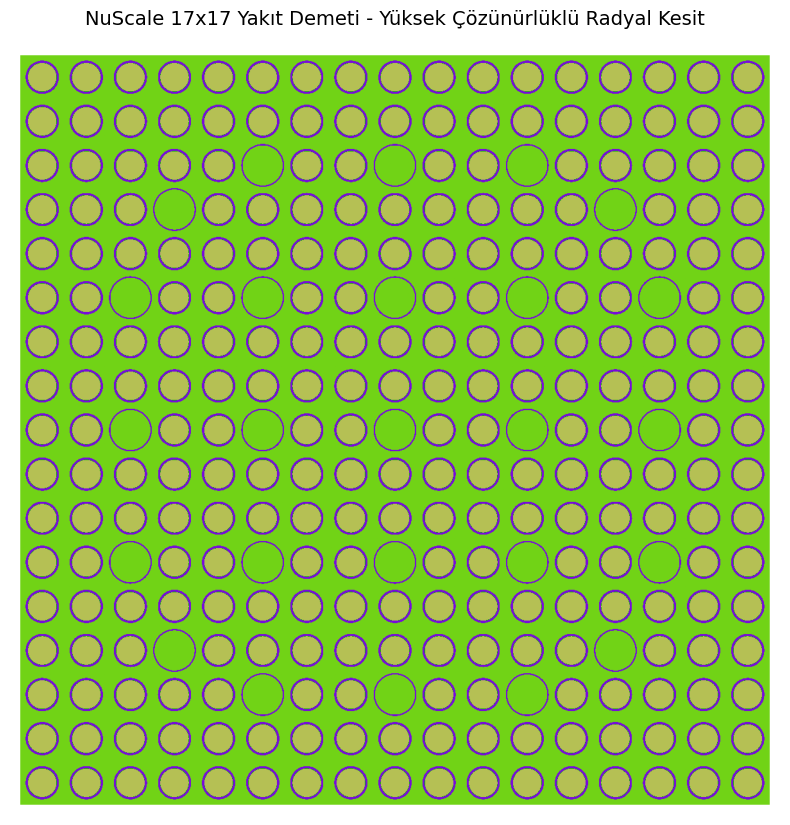

In [1]:
import openmc
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

print("Geometri yüksek çözünürlükle çiziliyor.")

# 1. Çizim Nesnesini (Plot) Oluştur
plot = openmc.Plot()
plot.filename = 'nuscale_radial_plot'
# Tüm 17x17 matrisi kapsayacak genişlik (Yaklaşık 22x22 cm)
plot.width = (22.0, 22.0) 
plot.pixels = (1200, 1200) # 1200x1200 piksel HD kalite
plot.basis = 'xy' # Kuşbakışı (radyal) kesit
plot.origin = (0.0, 0.0, 0.0)
plot.color_by = 'material' 

# 2. OpenMC'ye Çizimi Yaptır
plots = openmc.Plots([plot])
plots.export_to_xml()
openmc.plot_geometry() 

try:
    img = mpimg.imread('nuscale_radial_plot.png')
    plt.figure(figsize=(10, 10))
    plt.imshow(img)
    plt.axis('off')
    plt.title('NuScale 17x17 Yakıt Demeti - Yüksek Çözünürlüklü Radyal Kesit', fontsize=14, pad=15)
    plt.show()
except FileNotFoundError:
    print("Çizim dosyası bulunamadı.")

Enerji Spektrumu sensörleri hazırlanıyor.

-Enerji Spektrumu İçin OpenMC Çalışıyor


Sonuçlar grafiğe dökülüyor.


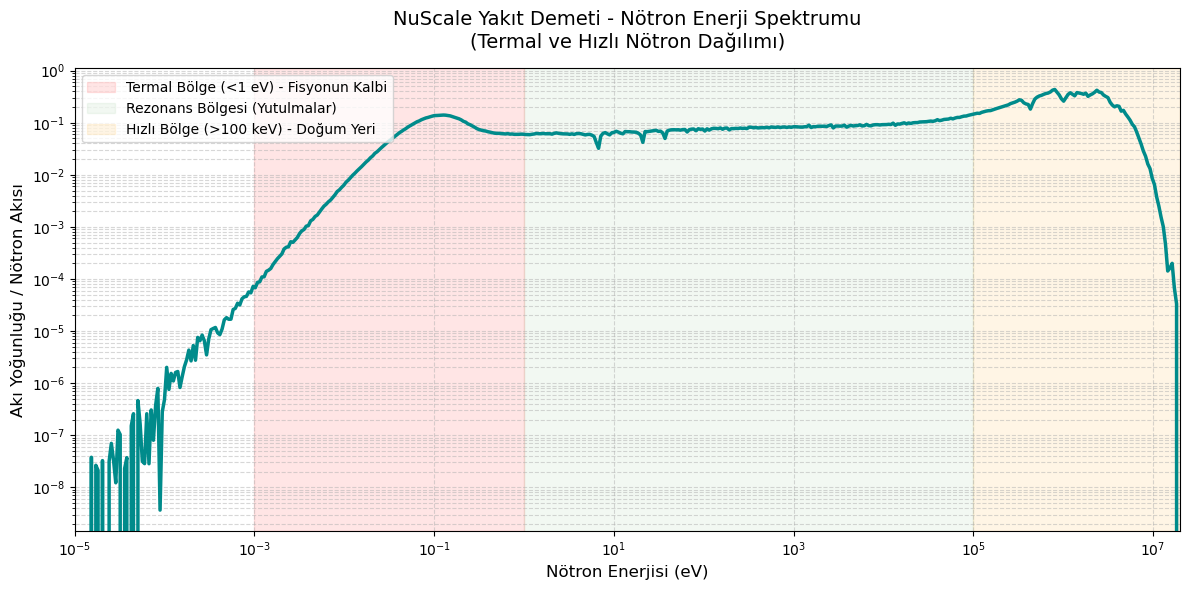

In [2]:
import openmc
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

print("Enerji Spektrumu sensörleri hazırlanıyor.")

# 1. LOGARİTMİK ENERJİ FİLTRESİ (1e-5 eV ile 2e7 eV arası 500 parça)
energy_bins = np.logspace(-5, 7.3, 500) 
energy_filter = openmc.EnergyFilter(energy_bins)

spectrum_tally = openmc.Tally(name='Notron_Spektrumu')
spectrum_tally.filters = [energy_filter]
spectrum_tally.scores = ['flux']

# Sensörü XML'e yaz
tallies = openmc.Tallies([spectrum_tally])
tallies.export_to_xml()

# 2. KISA SİMÜLASYONU TETİKLE
print("\n-Enerji Spektrumu İçin OpenMC Çalışıyor\n")
openmc.config['cross_sections'] = 'endfb-vii.1-hdf5/cross_sections.xml'
openmc.run(output=False)

print("\nSonuçlar grafiğe dökülüyor.")
statepoint_files = glob.glob('statepoint.*.h5')
latest_sp = max(statepoint_files, key=os.path.getctime)

with openmc.StatePoint(latest_sp) as sp:
    t = sp.get_tally(name='Notron_Spektrumu')
    flux = t.mean.flatten()

energy_centers = np.sqrt(energy_bins[:-1] * energy_bins[1:])

# 4. PROFESYONEL SPEKTRUM GÖRSELLEŞTİRMESİ
plt.figure(figsize=(12, 6))
plt.loglog(energy_centers, flux, color='darkcyan', linewidth=2.5)

plt.grid(True, which="both", ls="--", alpha=0.5)
plt.xlabel('Nötron Enerjisi (eV)', fontsize=12)
plt.ylabel('Akı Yoğunluğu / Nötron Akısı', fontsize=12)
plt.title('NuScale Yakıt Demeti - Nötron Enerji Spektrumu\n(Termal ve Hızlı Nötron Dağılımı)', fontsize=14, pad=15)

plt.axvspan(1e-3, 1, color='red', alpha=0.1, label='Termal Bölge (<1 eV) - Fisyonun Kalbi')
plt.axvspan(1, 1e5, color='green', alpha=0.05, label='Rezonans Bölgesi (Yutulmalar)')
plt.axvspan(1e5, 2e7, color='orange', alpha=0.1, label='Hızlı Bölge (>100 keV) - Doğum Yeri')

plt.legend(loc='upper left', fontsize=10)
plt.xlim(1e-5, 2e7)
plt.tight_layout()
plt.show()

İleri Düzey Nötronik Sensörler Yükleniyor.

 Gelişmiş Analiz Simülasyonu 



/home/busra/miniconda3/envs/openmc/lib/python3.11/site-packages/openmc/mixin.py:70: IDWarning: Another Filter instance already exists with id=1.
  warn(msg, IDWarning)
/home/busra/miniconda3/envs/openmc/lib/python3.11/site-packages/openmc/mixin.py:70: IDWarning: Another Tally instance already exists with id=1.
  warn(msg, IDWarning)



Sonuçlar Analiz Ediliyor.


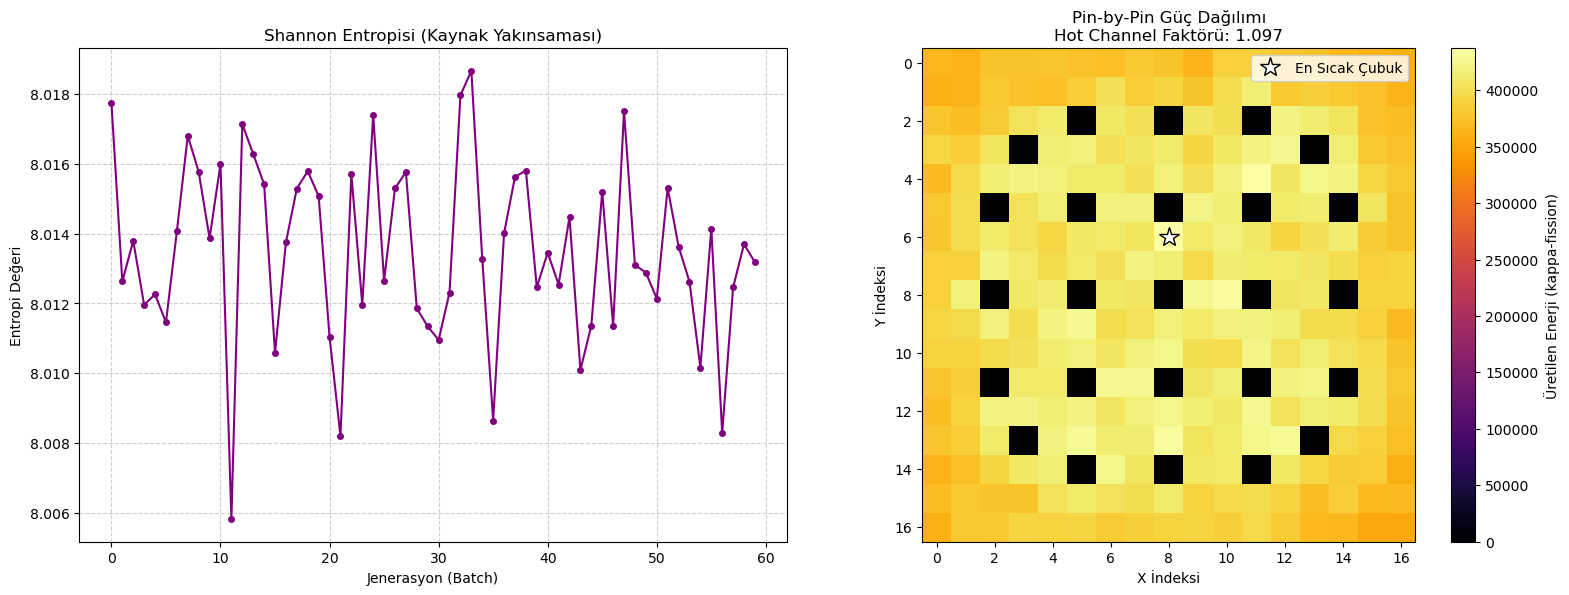

=== REAKSİYON İSTATİSTİKLERİ ===
Toplam (n,2n) Nötron Çoğalma Oranı : 1.49038e-03
Toplam (n,gamma) Yutulma Oranı     : 3.91158e-01
Hot Channel (Güç Zirvesi) Faktörü  : 1.097 (Güvenli Sınır genelde < 1.5'tir)


In [4]:
import openmc
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

print("İleri Düzey Nötronik Sensörler Yükleniyor.")

rod_pitch_cm = 0.496 * 2.54 
nuscale_offset = (17 * rod_pitch_cm) / 2.0

# 1. SHANNON ENTROPİSİ (Kaynak Yakınsaması İçin Ağ)
# Nötronların homojen dağılıp dağılmadığını ölçecek 17x17 ızgara
entropy_mesh = openmc.RegularMesh()
entropy_mesh.dimension = [17, 17, 1]
entropy_mesh.lower_left = [-nuscale_offset, -nuscale_offset, -100.0]
entropy_mesh.upper_right = [nuscale_offset, nuscale_offset, 100.0]

settings = openmc.Settings.from_xml()
settings.entropy_mesh = entropy_mesh
settings.export_to_xml()

# 2. PİN-BY-PİN GÜÇ VE REAKSİYON SENSÖRLERİ
# Sadece 17x17 boyutunda (her hücreye bir yakıt çubuğu düşecek şekilde) bir mesh
pin_mesh = openmc.RegularMesh()
pin_mesh.dimension = [17, 17]
pin_mesh.lower_left = [-nuscale_offset, -nuscale_offset]
pin_mesh.upper_right = [nuscale_offset, nuscale_offset]

pin_tally = openmc.Tally(name='Pin_Power_and_Reactions')
pin_tally.filters = [openmc.MeshFilter(pin_mesh)]

# kappa-fission: Fisyon sonucu ortaya çıkan ve bölgede soğurulan GERÇEK ısı enerjisi (Güç)
# (n,2n): 1 nötron girer, 2 nötron çıkar (Nötron çoğaltıcı etki)
# (n,gamma): Nötron yutulur ve gama ışını yayılır (Parçalanma olmaz)
pin_tally.scores = ['kappa-fission', '(n,2n)', '(n,gamma)']

tallies = openmc.Tallies.from_xml()
tallies.append(pin_tally)
tallies.export_to_xml()

# 3. SİMÜLASYONU ÇALIŞTIR
print("\n Gelişmiş Analiz Simülasyonu \n")
openmc.run(output=False)

# 4. SONUÇLARI OKU VE GÖRSELLEŞTİR
print("\nSonuçlar Analiz Ediliyor.")
statepoint_files = glob.glob('statepoint.*.h5')
latest_sp = max(statepoint_files, key=os.path.getctime)

with openmc.StatePoint(latest_sp) as sp:
    entropy = sp.entropy
    
    # Pin Gücü ve Reaksiyonları Çek
    t = sp.get_tally(name='Pin_Power_and_Reactions')
    
    power_matrix = t.get_slice(scores=['kappa-fission']).mean.reshape((17, 17))
    n2n_rate = t.get_slice(scores=['(n,2n)']).mean.sum()
    ngamma_rate = t.get_slice(scores=['(n,gamma)']).mean.sum()

power_matrix = np.flipud(power_matrix)

# Hot Channel Factor (En Sıcak Çubuk) Hesaplama
avg_power = np.mean(power_matrix[power_matrix > 0])
max_power = np.max(power_matrix)
hot_channel_factor = max_power / avg_power

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Sol Grafik: Shannon Entropisi
axes[0].plot(entropy, marker='o', color='purple', markersize=4)
axes[0].set_title('Shannon Entropisi (Kaynak Yakınsaması)')
axes[0].set_xlabel('Jenerasyon (Batch)')
axes[0].set_ylabel('Entropi Değeri')
axes[0].grid(True, linestyle='--', alpha=0.6)

# Sağ Grafik: Pin-by-Pin Güç Dağılımı
im = axes[1].imshow(power_matrix, interpolation='nearest', cmap='inferno')
axes[1].set_title(f'Pin-by-Pin Güç Dağılımı\nHot Channel Faktörü: {hot_channel_factor:.3f}')
axes[1].set_xlabel('X İndeksi')
axes[1].set_ylabel('Y İndeksi')
fig.colorbar(im, ax=axes[1], label='Üretilen Enerji (kappa-fission)')

# En sıcak çubuğu (Hot Channel) işaretle
max_idx = np.unravel_index(np.argmax(power_matrix), power_matrix.shape)
axes[1].plot(max_idx[1], max_idx[0], 'w*', markersize=15, markeredgecolor='black', label='En Sıcak Çubuk')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

print("=== REAKSİYON İSTATİSTİKLERİ ===")
print(f"Toplam (n,2n) Nötron Çoğalma Oranı : {n2n_rate:.5e}")
print(f"Toplam (n,gamma) Yutulma Oranı     : {ngamma_rate:.5e}")
print(f"Hot Channel (Güç Zirvesi) Faktörü  : {hot_channel_factor:.3f} (Güvenli Sınır genelde < 1.5'tir)")